In [402]:
import pandas as pd
import numpy as np


In [ ]:
data = pd.read_csv("data/sit2stand/Results.csv", index_col=0)
data

,id,OA_status,age,gender,BMI,Global03,cadence_per_min,avg_time_between_distance_peaks_s,std_time_between_distance_peaks_s,avg_max_standing_velocity,std_max_standing_velocity,avg_max_sitting_velocity,std_max_sitting_velocity,avg_time_between_max_stand_and_sit_velocity_s,std_time_between_max_stand_and_sit_velocity_s,avg_velocity_ratio,std_velocity_ratio
0,RyGoZ15h,0,56,1,28.120000,2,31.218781,2.252250,0.050050,0.443016,0.024993,0.460322,0.031054,0.834167,0.036551,0.962405,0.066960
1,sUlatygS,1,65,1,20.524438,2,31.547400,2.235567,0.033367,0.508926,0.060354,0.445285,0.013635,0.814147,0.034027,1.142923,0.035356
2,VPQJGG4D,0,68,0,37.302041,3,15.964523,4.489583,0.336412,0.287069,0.031906,0.265315,0.004630,1.416667,0.136931,1.081996,0.018826
3,bb8G8L2i,0,57,0,25.014922,3,24.390244,2.933333,0.222361,0.423130,0.046916,0.360967,0.037406,0.933333,0.111555,1.172213,0.136214
4,MD7hICzN,1,73,0,27.664352,4,21.305709,3.286617,0.347959,0.364318,0.089053,0.341752,0.068807,1.194527,0.424898,1.066032,0.198085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,6MFubdNK,0,51,1,23.170166,4,31.514085,2.304469,0.271669,0.386780,0.031667,0.285287,0.023303,1.052514,0.034183,1.355759,0.114120
85,vJppbtm5,0,55,1,25.840160,3,31.437094,2.252250,0.106825,0.432020,0.030281,0.431550,0.053115,0.820820,0.129401,1.001090,0.140570
86,EzIx57IR,0,66,1,31.954545,3,38.626609,1.816667,0.037268,0.413768,0.021878,0.374023,0.029060,0.833333,0.101105,1.106263,0.087597
87,jasA5s93,0,53,0,32.997959,3,22.784810,3.183333,0.203443,0.429699,0.054161,0.349260,0.051415,0.960000,0.175626,1.230314,0.163308


In [451]:
X = data.drop(columns=["id", "OA_status",'Global03'])
global03 = np.array(data['Global03'].values)
y = (global03 >= 4).astype(int)  # Binary classification: 0 for Global03 < 4, 1 for Global03 >= 4


In [452]:
print("y value counts:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c}")

y value counts:
  Class 0: 38
  Class 1: 51


We can try to fit a simple linear model with all the features

In [453]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Random Forest classifier
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logisticregression', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

# Train
pipe.fit(X_train, y_train)
# Evaluate
y_pred = pipe.predict(X_test)
print("Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8083333333333333

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.75      0.78        12
           1       0.81      0.87      0.84        15

    accuracy                           0.81        27
   macro avg       0.82      0.81      0.81        27
weighted avg       0.82      0.81      0.81        27

Confusion matrix:
 [[ 9  3]
 [ 2 13]]


The accuracy is ok, we see that some of the subjects are misclassified.

Lest visualize the coefficients, we can do this because the features are scaled. 

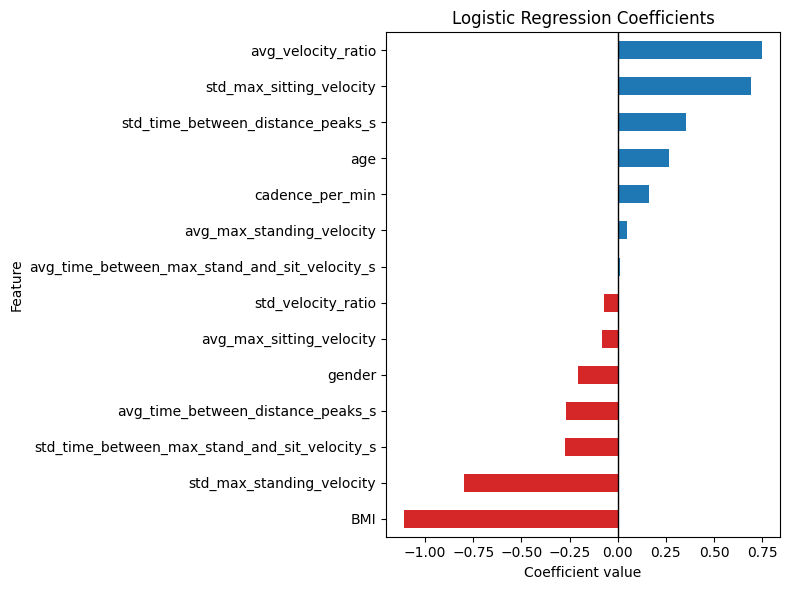

In [447]:
import matplotlib.pyplot as plt

if not (hasattr(pipe, "named_steps") and "logisticregression" in pipe.named_steps):
    raise ValueError("pipe is not a LogisticRegression pipeline.")

coef = pd.Series(
    pipe.named_steps["logisticregression"].coef_[0],
    index=X_train.columns,
    name="coefficient"
).sort_values()

plt.figure(figsize=(8, 6))
coef.plot(kind="barh", color=["#d62728" if v < 0 else "#1f77b4" for v in coef])
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

We can now remove some features, to see if the model improves

In [465]:
X_new = X.copy()
X_new = X_new[[
        'age',
        'BMI',
        'gender',

        # 'avg_max_sitting_velocity',
        # 'std_max_sitting_velocity',

        # 'std_max_standing_velocity',
        # 'avg_max_standing_velocity',
        
        # 'avg_velocity_ratio',
        # 'std_velocity_ratio',

        # 'avg_time_between_distance_peaks_s',
        # 'std_time_between_distance_peaks_s',

        # 'avg_time_between_max_stand_and_sit_velocity_s',
        # 'std_time_between_max_stand_and_sit_velocity_s',

        # 'cadence_per_min',     
]]

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y, test_size=0.3, random_state=42, stratify=y
)

# Random Forest classifier
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logisticregression', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

# clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
# Train
pipe.fit(X_train_new, y_train_new)

# Evaluate
y_pred = pipe.predict(X_test_new)
print("Accuracy:", balanced_accuracy_score(y_test_new, y_pred))
print("\nClassification report:\n", classification_report(y_test_new, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test_new, y_pred))

Accuracy: 0.6583333333333333

Classification report:
               precision    recall  f1-score   support

           0       0.64      0.58      0.61        12
           1       0.69      0.73      0.71        15

    accuracy                           0.67        27
   macro avg       0.66      0.66      0.66        27
weighted avg       0.66      0.67      0.66        27

Confusion matrix:
 [[ 7  5]
 [ 4 11]]


We can now do a search in a parameter grid with cross-validation

In [469]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Linear model pipeline + feature selection
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=5000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

linear_param_grid = {
    "model__C": [1, 10,],
    "model__penalty": ["l1","l2",],
    "model__solver": ["liblinear"],  # supports l1/l2
    "model__class_weight": [None,"balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

linear_search = GridSearchCV(
    estimator=pipe,
    param_grid=linear_param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

linear_search.fit(X_train, y_train)

best_linear_model = linear_search.best_estimator_
y_pred_linear = best_linear_model.predict(X_test)

print("Best CV score:", linear_search.best_score_)
print("Best params:", linear_search.best_params_)
print("Test accuracy:", balanced_accuracy_score(y_test, y_pred_linear))
print("\nClassification report:\n", classification_report(y_test, y_pred_linear))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_linear))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best CV score: 0.7057142857142857
Best params: {'model__C': 1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Test accuracy: 0.8083333333333333

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.75      0.78        12
           1       0.81      0.87      0.84        15

    accuracy                           0.81        27
   macro avg       0.82      0.81      0.81        27
weighted avg       0.82      0.81      0.81        27

Confusion matrix:
 [[ 9  3]
 [ 2 13]]


In [470]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Linear model pipeline + feature selection
linear_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=mutual_info_classif)),
    ('model', LogisticRegression(random_state=42, max_iter=5000))
])


k_max = X_train.shape[1]
linear_param_grid = {
    "selector__k": list(range(1, k_max + 1)),
    "model__C": [1, 10, ],
    "model__penalty": ["l1","l2",],
    "model__solver": ["liblinear"],  # supports l1/l2
    "model__class_weight": ["balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

linear_search = GridSearchCV(
    estimator=linear_pipe,
    param_grid=linear_param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

linear_search.fit(X_train, y_train)

best_linear_model = linear_search.best_estimator_
y_pred_linear = best_linear_model.predict(X_test)

print("Best CV score:", linear_search.best_score_)
print("Best params:", linear_search.best_params_)
print("Test accuracy:", balanced_accuracy_score(y_test, y_pred_linear))
print("\nClassification report:\n", classification_report(y_test, y_pred_linear))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_linear))

selected_features = X_train.columns[
    best_linear_model.named_steps["selector"].get_support()
].tolist()
print("\nSelected features:", selected_features)

Fitting 5 folds for each of 56 candidates, totalling 280 fits
Best CV score: 0.7064102564102563
Best params: {'model__C': 1, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear', 'selector__k': 8}
Test accuracy: 0.775

Classification report:
               precision    recall  f1-score   support

           0       0.75      0.75      0.75        12
           1       0.80      0.80      0.80        15

    accuracy                           0.78        27
   macro avg       0.78      0.78      0.78        27
weighted avg       0.78      0.78      0.78        27

Confusion matrix:
 [[ 9  3]
 [ 3 12]]

Selected features: ['BMI', 'cadence_per_min', 'avg_time_between_distance_peaks_s', 'avg_max_standing_velocity', 'std_max_standing_velocity', 'std_max_sitting_velocity', 'avg_time_between_max_stand_and_sit_velocity_s', 'avg_velocity_ratio']


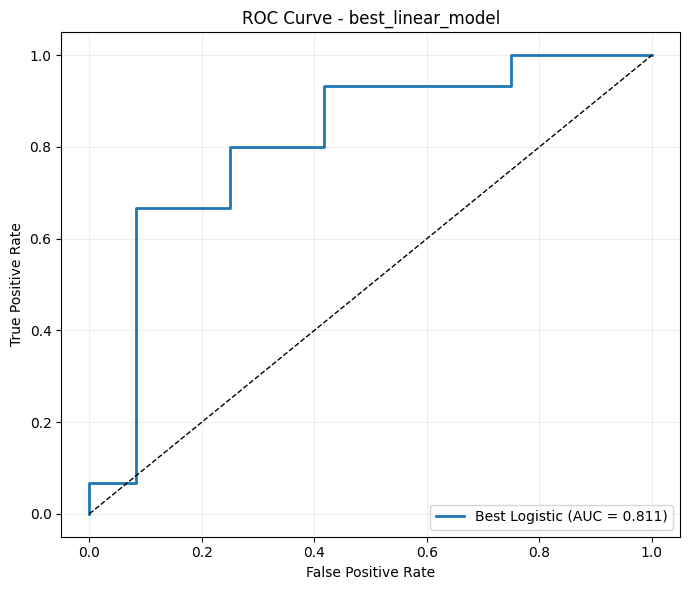

ROC-AUC (best_linear_model): 0.811


In [473]:

y_score_linear = best_linear_model.predict_proba(X_test)[:, 1]
fpr_linear, tpr_linear, _ = roc_curve(y_test, y_score_linear)
auc_linear = roc_auc_score(y_test, y_score_linear)

plt.figure(figsize=(7, 6))
plt.plot(fpr_linear, tpr_linear, lw=2, label=f"Best Logistic (AUC = {auc_linear:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - best_linear_model")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"ROC-AUC (best_linear_model): {auc_linear:.3f}")